In [49]:
import importlib
import plant
importlib.reload (plant)
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.spatial.transform import Rotation as R

from plant import DroneConfig, DronePlant, RK4_step, b2w_rotatation, g

# Trajectory Visualizer

In [50]:
def input(t, config):
    hover = config.mass * g
    thrust = hover
    torques = np.zeros(3)

    if 0.0 <= t < 2.0:
        thrust = 1.2 * hover
        if 0.2 <= t < 0.8:
            torques[0] = 0.004
        elif 0.8 <= t < 1.4:
            torques[0] = -0.004

    elif 2.0 <= t < 5.0:
        thrust = hover

        if 2.2 <= t < 3.0:
            torques[1] = -0.004
        elif 3.0 <= t < 3.8:
            torques[1] = 0.004

        if 3.8 <= t < 4.4:
            torques[0] = -0.004
        elif 4.4 <= t < 5.0:
            torques[0] = 0.004

    elif 5.5 <= t < 9.0:
        thrust = 0.84 * hover

        if 5.5 <= t < 6.2:
            torques[1] = 0.004
        if 6.2 <= t < 6.9:
            torques[1] = -0.004

        if 5.5 <= t < 6.5:
            torques[0] = -0.006
        elif 6.5 <= t < 7.5:
            torques[0] = 0.006

    return thrust, torques

We expect to see 3 stage: 

Fly up + Roll: 
* height rises
* drone in (+)y direction

input + Pitch: 
* drone moves in (+)x & (+y) direction
* vx, vy should plataeu

Fly down + Roll: 
* height decreases
* drone moves in (+)x & (-)y direction
* angular velocity in x direction should plateau

The trajectory should look like a tilted 'U' letter

In [51]:
dt = 0.02
t0 = 0
t_end = 10
times = [t0]
y0 = np.zeros(12)
config = DroneConfig(
    mass = 2.0, 
    inertia = np.diag([0.01, 0.01, 0.02]), 
    length = 0.2, 
    kd = 0.0, 
    kt = 0.0, 
    kb = 0.0, 
)
state_vec = [y0.copy()]

def f(t, y):
    thrust, torques = input(t, config)
    plant = DronePlant(config, y)
    return plant.state_derivatives(thrust, torques)

t = t0
y = y0.copy()
while (t < t_end): 
    y = RK4_step(f, t, y, dt)
    t = t + dt 
    times.append(t)
    state_vec.append (y)

state_comp = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'phi', 'theta', 'psi', 'wx', 'wy', 'wz']
df = pd.DataFrame(state_vec, columns = state_comp)
df.insert (0, 'time', times)

In [52]:
times = [t0]
state_vec = [y0.copy()]
t = t0
y = y0.copy()
input_vec = []

while t < t_end:
    thrust, torques = input(t, config)
    input_vec.append ([t, thrust])
    y = RK4_step(f, t, y, dt)
    t = t + dt 
    times.append (t)
    state_vec.append (y.copy())
df = pd.DataFrame(state_vec, columns = state_comp)
df.insert (0, 'time', times)    

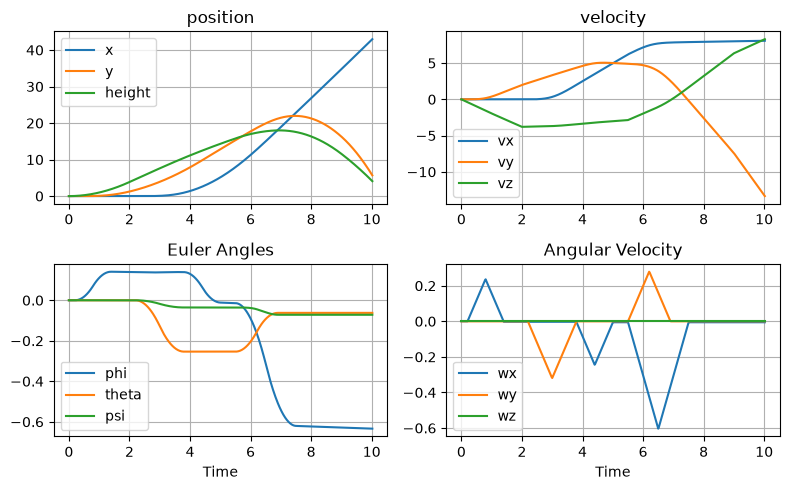

In [58]:
height = -df['z']
fig, axs = plt.subplots (2, 2, figsize = (8, 5))

axs[0, 0].plot (df['time'], df['x'], label = 'x')
axs[0, 0].plot (df['time'], df['y'], label = 'y')
axs[0, 0].plot (df['time'], height, label = 'height')
axs[0, 0].set_title ('position') 
axs[0, 0].legend() 
axs[0, 0].grid (True)

axs[0, 1].plot (df['time'], df['vx'], label = 'vx')
axs[0, 1].plot (df['time'], df['vy'], label = 'vy')
axs[0, 1].plot (df['time'], df['vz'], label = 'vz')
axs[0, 1].set_title ('velocity')
axs[0, 1].legend() 
axs[0, 1].grid(True)

axs[1, 0].plot (df['time'], (df['phi']), label = 'phi')
axs[1, 0].plot (df['time'], (df['theta']), label = 'theta')
axs[1, 0].plot (df['time'], (df['psi']), label = 'psi')
axs[1, 0].set_title ('Euler Angles')
axs[1, 0].legend()
axs[1, 0].grid (True) 

axs[1, 1].plot (df['time'], df['wx'], label = 'wx')
axs[1, 1].plot (df['time'], df['wy'], label = 'wy')
axs[1, 1].plot (df['time'], df['wz'], label = 'wz')
axs[1, 1].set_title ('Angular Velocity')
axs[1, 1].legend()
axs[1, 1].grid (True) 

axs[1, 0].set_xlabel('Time')
axs[1, 1].set_xlabel('Time')

plt.tight_layout()
plt.show() 

Angular Velocity: 
* wx, wy, wz changes linearly with the torques: correct 

Velocity: 
* vy increases in (+), then plateau, and increases in (-): correct
* vx only increases in second phase (hovering in positive x axis), and then plateau: correct 
* vz increases in (-) (flying up because Z-axis goes down), then changes slightly, and then increases in (+) (flying down): correct

Euler Angles: 
* phi, and theta changes as expected
* psi changes in [2.2, 3,0], and [5.5 6.2], because wy != 0 in those two intervals, affecting the function of psi dot, hence changing psi: correct

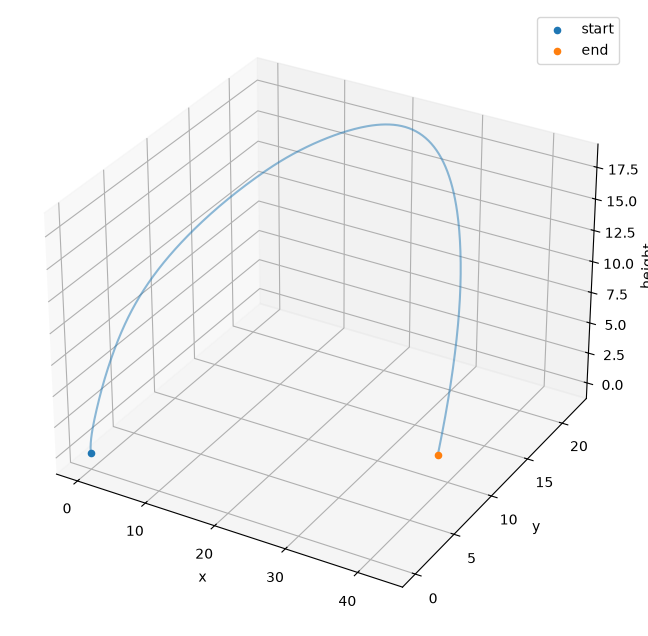

In [54]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot (projection = '3d')
ax.plot (df['x'], df['y'], height, alpha = 0.5)
ax.scatter (
    df['x'].iloc[0], 
    df['y'].iloc[0], 
    height.iloc[0],
    label = 'start', 
)
ax.scatter (
    df['x'].iloc[-1],
    df['y'].iloc[-1],
    height.iloc[-1],
    label = 'end'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('height')
ax.legend()

plt.show() 

The trajectory of the Drone moves as expected, creating a tilted 'U' letter

# Gimbal Lock Visualizer 

In [55]:
theta_l = np.linspace(np.deg2rad(70), np.deg2rad(89.90), 200)
theta_r = np.linspace(np.deg2rad(90.10), np.deg2rad(110), 200)
theta_rad = np.concatenate([theta_l, theta_r])
theta_deg = np.rad2deg(theta_rad)

phi_input_deg = 10.0
psi_input_deg = 20.0
phi_input_rad = np.deg2rad(phi_input_deg)
psi_input_rad = np.deg2rad(psi_input_deg)

wx = np.ones_like(theta_rad)
wy = 0.2 * np.ones_like(theta_rad)
wz = 0.5 * np.ones_like(theta_rad)

phi_dot = []
theta_dot = []
psi_dot = []

for theta, wx_i, wy_i, wz_i in zip(theta_rad, wx, wy, wz):
    euler_angle_matrix = np.array([
        [1, np.sin(phi_input_rad) * np.tan(theta), np.cos(phi_input_rad) * np.tan(theta)],
        [0, np.cos(phi_input_rad), -np.sin(phi_input_rad)],
        [0, np.sin(phi_input_rad) / np.cos(theta), np.cos(phi_input_rad) / np.cos(theta)],
    ])

    euler_dot = euler_angle_matrix @ np.array([wx_i, wy_i, wz_i])
    phi_dot.append(euler_dot[0])
    theta_dot.append(euler_dot[1])
    psi_dot.append(euler_dot[2])

phi_dot = np.array(phi_dot)
theta_dot = np.array(theta_dot)
psi_dot = np.array(psi_dot)

cos_theta_inverse = np.abs(1 / np.cos(theta_rad))

phi_recover = []
theta_recover = []
psi_recover = []

for theta in theta_rad:
    rotational_matrix = b2w_rotatation(phi_input_rad, theta, psi_input_rad)
    convert = R.from_matrix(rotational_matrix)
    phi_rec, theta_rec, psi_rec = convert.as_euler('ZYX')

    phi_recover.append(phi_rec)
    theta_recover.append(theta_rec)
    psi_recover.append(psi_rec)

phi_recover = np.rad2deg(phi_recover)
theta_recover = np.rad2deg(theta_recover)
psi_recover = np.rad2deg(psi_recover)


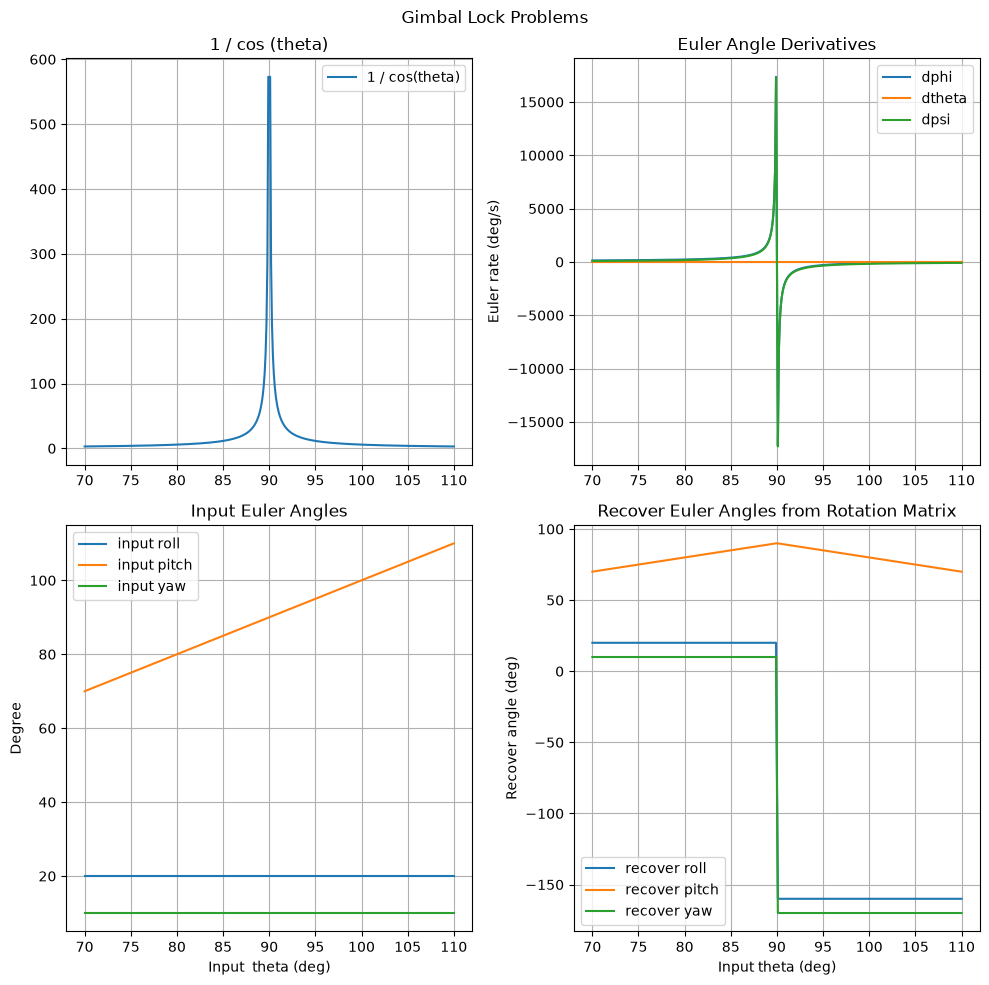

In [57]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].plot(theta_deg, cos_theta_inverse, label='1 / cos(theta)')
axs[0, 0].set_title('1 / cos (theta)')
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].plot(theta_deg, np.rad2deg(phi_dot), label='dphi')
axs[0, 1].plot(theta_deg, np.rad2deg(theta_dot), label='dtheta')
axs[0, 1].plot(theta_deg, np.rad2deg(psi_dot), label='dpsi')
axs[0, 1].set_ylabel('Euler rate (deg/s)')
axs[0, 1].set_title('Euler Angle Derivatives')
axs[0, 1].legend()
axs[0, 1].grid(True)

axs[1, 0].plot(theta_deg, np.full_like(theta_deg, psi_input_deg), label='input roll')
axs[1, 0].plot(theta_deg, theta_deg, label='input pitch')
axs[1, 0].plot(theta_deg, np.full_like(theta_deg, phi_input_deg), label='input yaw')
axs[1, 0].set_xlabel('Input  theta (deg)')
axs[1, 0].set_ylabel('Degree')
axs[1, 0].set_title('Input Euler Angles')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].plot(theta_deg, phi_recover, label='recover roll')
axs[1, 1].plot(theta_deg, theta_recover, label='recover pitch')
axs[1, 1].plot(theta_deg, psi_recover, label='recover yaw')
axs[1, 1].set_xlabel('Input theta (deg)')
axs[1, 1].set_ylabel('Recover angle (deg)')
axs[1, 1].set_title('Recover Euler Angles from Rotation Matrix')
axs[1, 1].legend(loc = 'lower left')
axs[1, 1].grid(True)

fig.suptitle('Gimbal Lock Problems')
plt.tight_layout()
plt.show()


Gimbal Lock happens when theta approaches either 90 or -90 deg, making cos(theta) approaches 0:

* 1 / cos (theta) approaches (+)infinity
* phi & psi approaches a vertical asymptotate --> making any calculations using Euler Rates unstable 
* When using the Euler Rotational Matrix to derive Euler Angles during Gimbal Lock, the output is unreliable